!pip install fluprodia tespy #convert this cell to code the first time you run to install the packages

## Parameters

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')
from HPS_regular import RegularHeatPumpStudy

dT_heat_exchanger = 8
T_cond = 50
T_ambient = 10
T_evap = T_ambient-dT_heat_exchanger
N=1
wf="R290"
%load_ext autoreload
%autoreload 2
plt.style.use('default')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Regular Heat Pump for comparison

Regular: DeltaT = 109.47 K
flowrate: 4.709295639486772 l/s


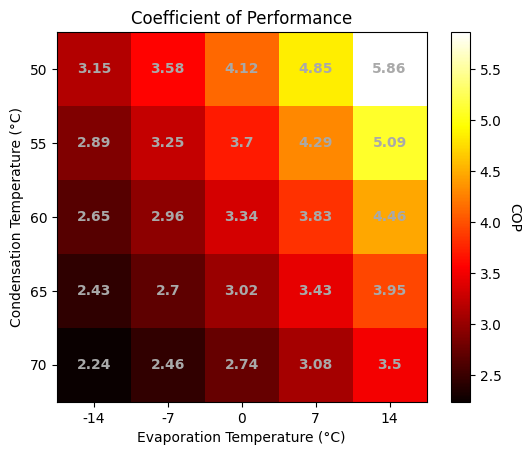

In [9]:


regular_study = RegularHeatPumpStudy(working_fluid=wf
                                     ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap,                                       
                                     ).solve()
print(f"Regular: DeltaT = {regular_study.get_delta_T():.2f} K")
print(f"flowrate: {regular_study.conn['evaporator-compressor'].get_attr('v').val} l/s")
#regular_study.plot_ts_diag("output/regular_heat_pump_ts_diagram")
#regular_study.plot_logph_diag("output/regular_heat_pump_logph_diagram")
regular_efficiency_plot = regular_study.plot_efficiency("output/regular_heat_pump_efficiency")


# Intercooling effectiveness

In [10]:
from HPS_intercooler import IntercoolerHeatPumpStudy


intercooler_study = IntercoolerHeatPumpStudy(working_fluid=wf, N=N
                                            ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap
                                            ).solve()

print(f"Intercooler: DeltaT = {intercooler_study.get_delta_T():.2f} K")
#intercooler_study.plot_ts_diag("output/intercooler_ts_diagram", x_max=3000)
#intercooler_study.plot_logph_diag("output/intercooler_logph_diagram", x_max=800)
#intercooler_study.plot_efficiency("output/intercooler_heat_pump_efficiency.svg")
#intercooler_study.plot_relative_efficiency("output/intercooler_heat_pump_relative_efficiency.svg", regular_efficiency_matrix)

Intercooler: DeltaT = 83.25 K


# Energy Recovery Study

Energy recovery: DeltaT = 60.22 K


array([[27.20240225, 22.15974508, 16.42819009,  9.83175557,  2.10139097],
       [29.06092758, 24.21227107, 18.75265172, 12.55185955,  5.41597208],
       [31.21657227, 26.53859368, 21.30701618, 15.42438649,  8.74800095],
       [33.70048631, 29.17581252, 24.13904184, 18.51695875, 12.20320668],
       [36.56460367, 32.1813759 , 27.31469421, 21.90984177, 15.88720896]])

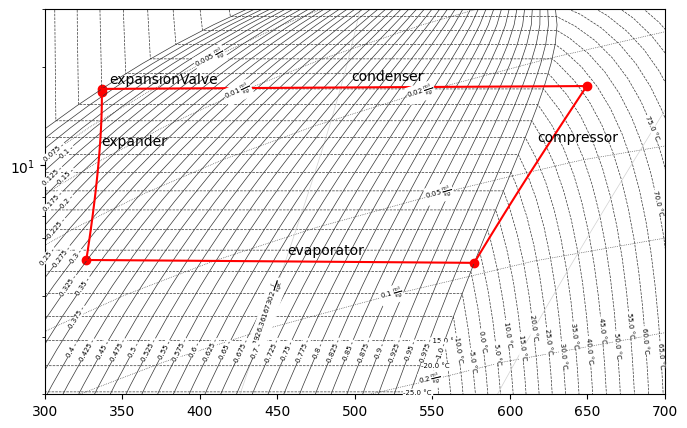

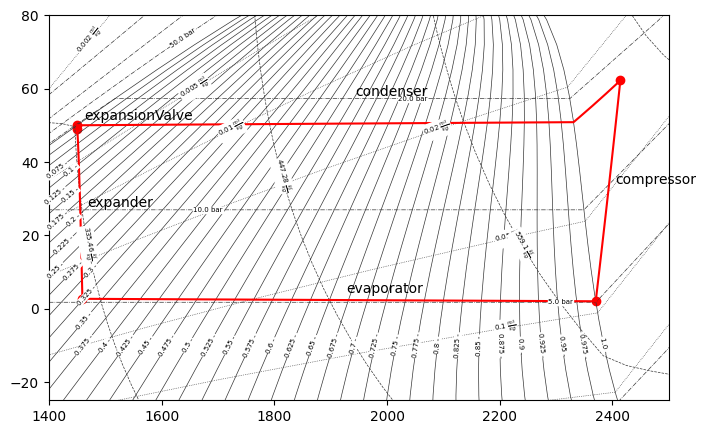

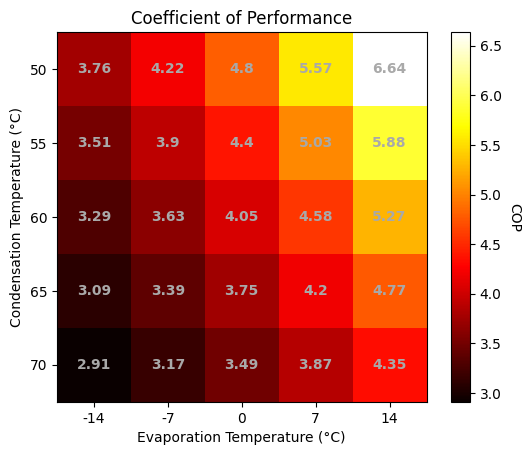

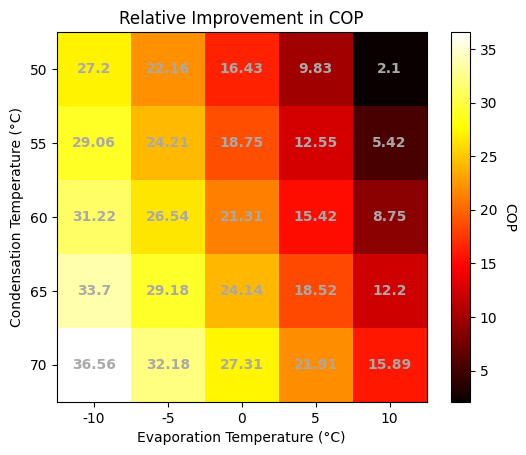

In [20]:
from HPS_regular import RegularHeatPumpStudy

energy_recovery_study = RegularHeatPumpStudy(working_fluid=wf, expansion_device="expander"
                                                        ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap
                                                        ).solve()

# calculate maximum temperature difference between the compressor intake and outlet
print(f"Energy recovery: DeltaT = {energy_recovery_study.get_delta_T():.2f} K")
energy_recovery_study.plot_logph_diag("output/energy_recovery_logph_diagram", x_min=300, x_max=700, y_min=2, y_max=30)
energy_recovery_study.plot_ts_diag("output/energy_recovery_ts_diagram", y_min=-25, y_max=80, x_min=1400, x_max=2500)

energy_recovery_study.plot_efficiency("output/energy_recovery_heat_pump_efficiency")
regular_efficiency_matrix = regular_study.efficiency_matrix()
energy_recovery_study.plot_relative_efficiency("output/energy_recovery_heat_pump_relative_efficiency", regular_efficiency_matrix)

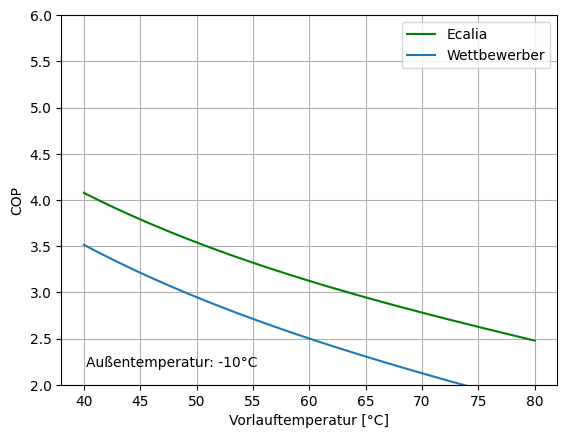

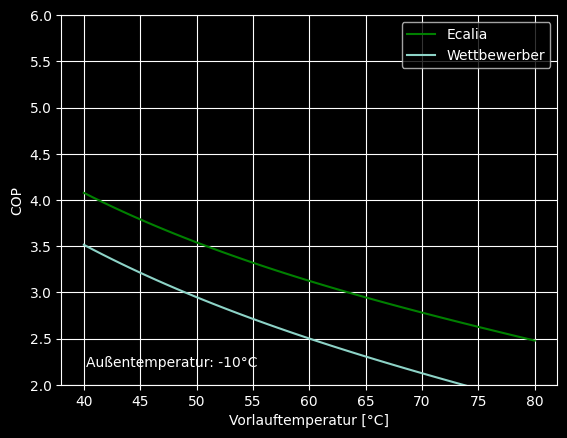

In [ ]:

plt.show()

T_cond = np.linspace(40, 80, 50)
COP_regular = np.zeros_like(T_cond)
COP_expander = np.zeros_like(T_cond)
for i, T in enumerate(T_cond):
    regular_study.set_boundary_conditions(T_cond=T, T_evap=T_evap)
    energy_recovery_study.set_boundary_conditions(T_cond=T, T_evap=T_evap)
    
    regular_study.solve()
    energy_recovery_study.solve()
    
    COP_regular[i] = regular_study.calculate_cop()
    COP_expander[i] = energy_recovery_study.calculate_cop()


plt.plot(T_cond, COP_expander, label="Ecalia", color="green")
plt.plot(T_cond, COP_regular, label="Wettbewerber")
plt.xlabel("Vorlauftemperatur [°C]")
plt.ylabel("COP")
plt.legend()
plt.grid()
# add a note about the outside temperature
plt.annotate(f"Außentemperatur: {T_ambient}°C", xy=(0.05, 0.05), xycoords='axes fraction')
plt.ylim(2,6)
plt.savefig(f"output/COP_condensation_temperature{T_ambient}.png")
plt.show()

# now let's plot this in dark mode with transparent background and inverted colors for the lines
plt.style.use('dark_background')
plt.plot(T_cond, COP_expander, label="Ecalia", color="green")
plt.plot(T_cond, COP_regular, label="Wettbewerber")
plt.xlabel("Vorlauftemperatur [°C]")
plt.ylabel("COP")
plt.legend()
plt.grid()
# add a note about the outside temperature
plt.annotate(f"Außentemperatur: {T_ambient}°C", xy=(0.05, 0.05), xycoords='axes fraction')
plt.ylim(2,6)
plt.savefig(f"output/COP_condensation_temperature{T_ambient}_dark.svg")
plt.show()


# Multistage Condenser Study

In [ ]:
from HPS_multistage_condenser import InternalCondenserHeatPumpStudy
internal_condenser_study = InternalCondenserHeatPumpStudy(working_fluid=wf, N=1, expansion_device="expander"
                                                    ).setup_network(
                                                    ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap, T_consumer=T_cond-5
                                                    ).solve(max_iter=200)
print(f"Internal condenser: DeltaT = {internal_condenser_study.get_delta_T():.2f} K")
internal_condenser_study.plot_logph_diag("output/internal_condenser_logph_diagram")
internal_condenser_study.plot_ts_diag("output/internal_condenser_ts_diagram", x_max=3000)
internal_condenser_study.plot_efficiency("output/multistage_heat_pump_efficiency")
internal_condenser_study.plot_relative_efficiency("output/multistage_heat_pump_relative_efficiency", expander_efficiency_matrix)

KeyError: 'expansionValve-expander'

# Vapor Injection Heat Pump Study

Vapor injection: DeltaT = 56.58 K


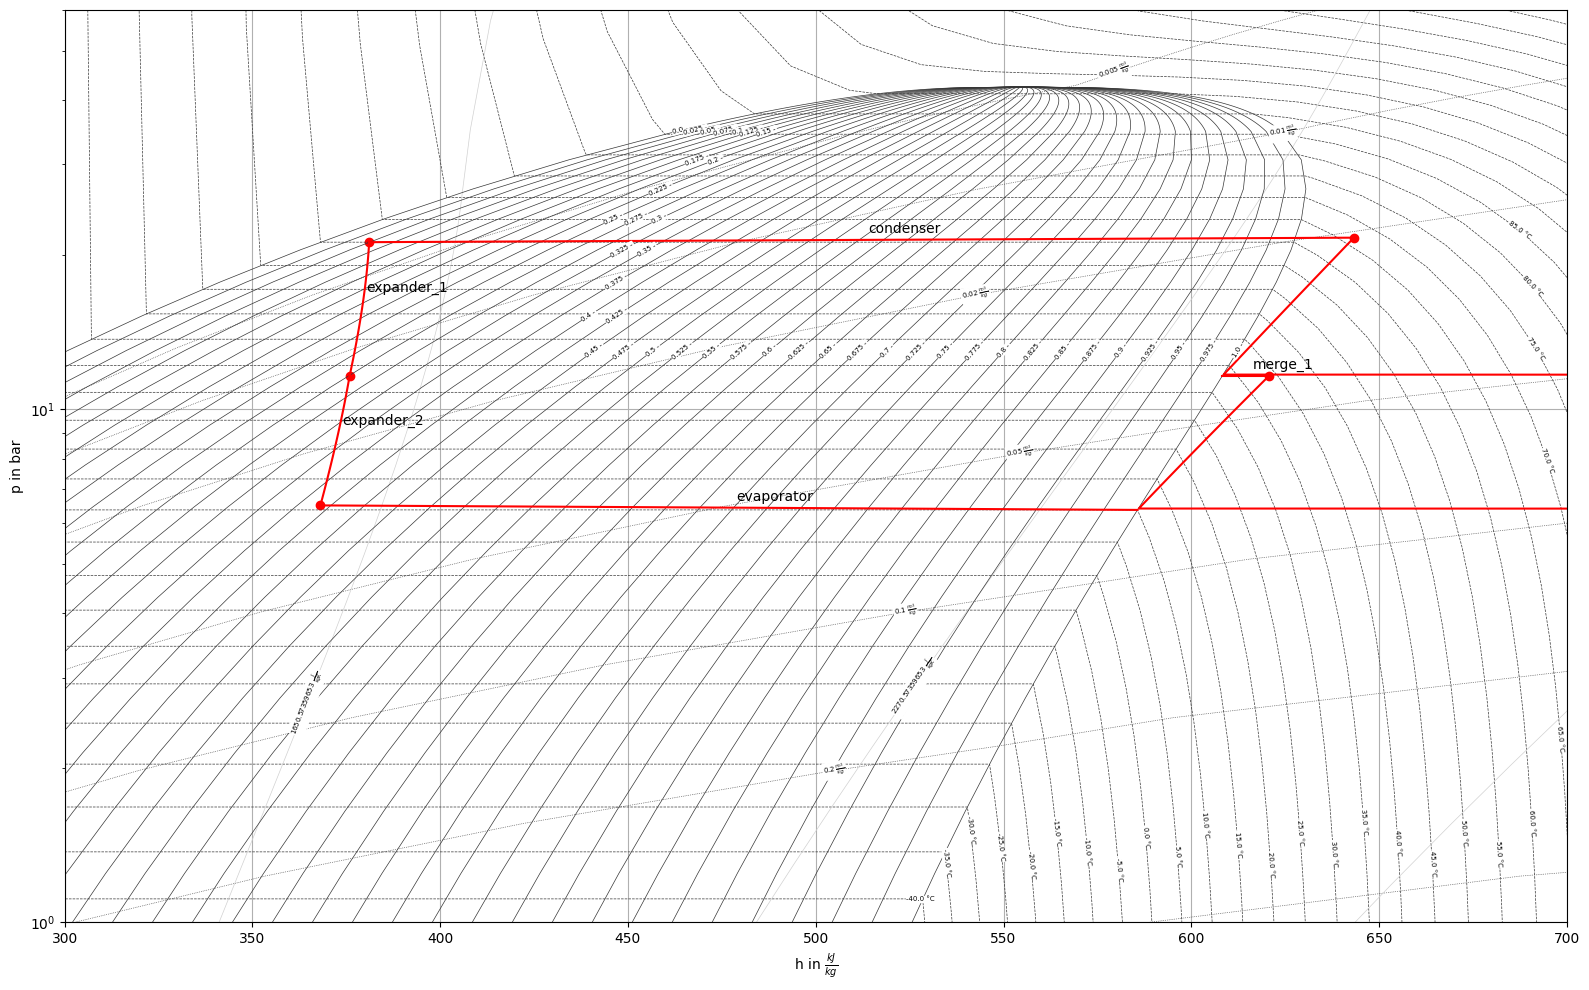

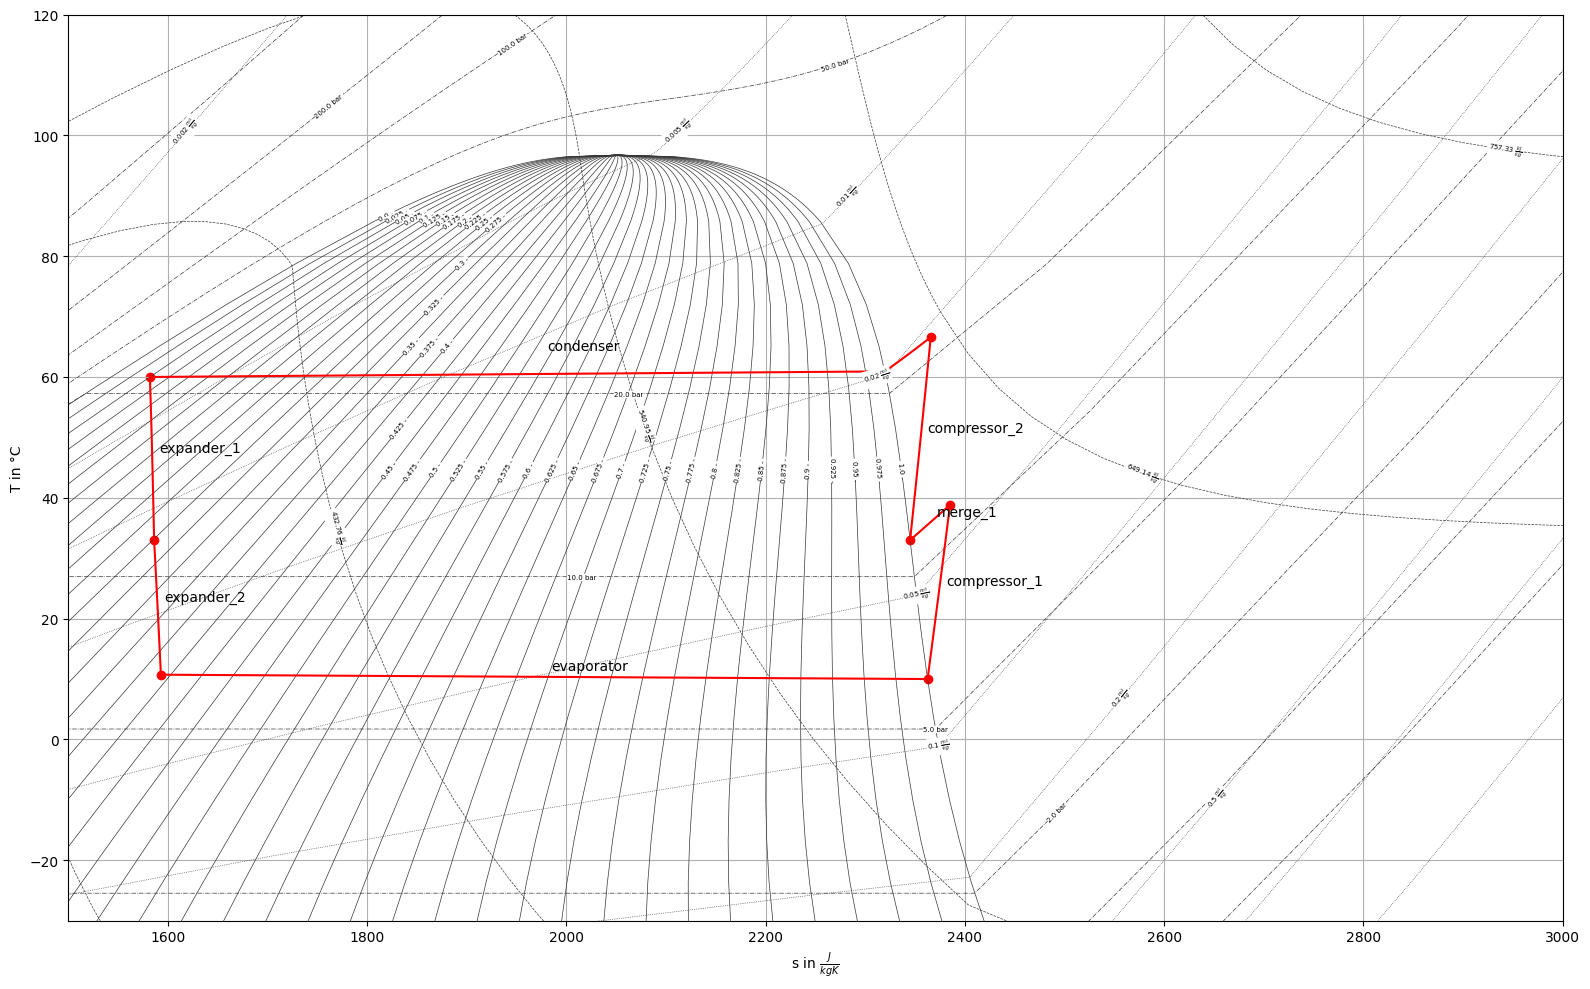

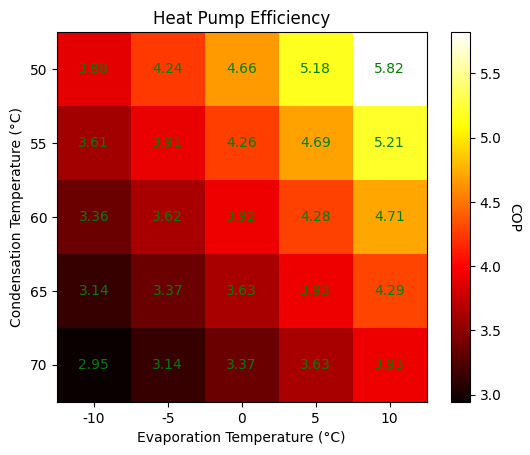

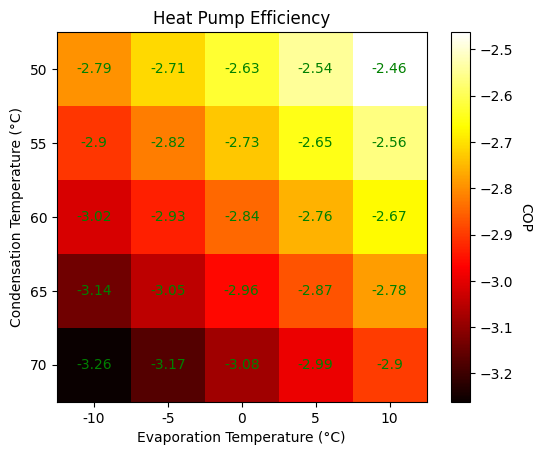

array([[-2.79407528, -2.71099849, -2.62762609, -2.54456915, -2.4626964 ],
       [-2.90392051, -2.81912904, -2.73386976, -2.64857148, -2.56383852],
       [-3.01781858, -2.93139125, -2.84440721, -2.75715266, -2.67003923],
       [-3.13654934, -3.04849622, -2.95986202, -2.87081273, -2.78160636],
       [-3.26123118, -3.17150644, -3.0812355 , -2.99047719, -2.89935755]])

In [ ]:
from HPS_vapor_injection import VaporInjectionHeatPumpStudy
vapor_injection_study = VaporInjectionHeatPumpStudy(working_fluid=wf, N=1, expansion_device="expander"
                                                    ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap
                                                    ).solve(max_iter=50)
print(f"Vapor injection: DeltaT = {vapor_injection_study.get_delta_T():.2f} K")
vapor_injection_study.plot_logph_diag(f"output/vapor_injection_{N}_logph_diagram", x_max=700)
vapor_injection_study.plot_ts_diag(f"output/vapor_injection_{N}_ts_diagram", x_max=3000)
vapor_injection_study.plot_efficiency(f"output/vapor_injection_{N}_heat_pump_efficiency")
vapor_injection_study.plot_relative_efficiency(f"output/vapor_injection_{N}_heat_pump_relative_efficiency", expander_efficiency_matrix)

Vapor injection: DeltaT = 54.94 K


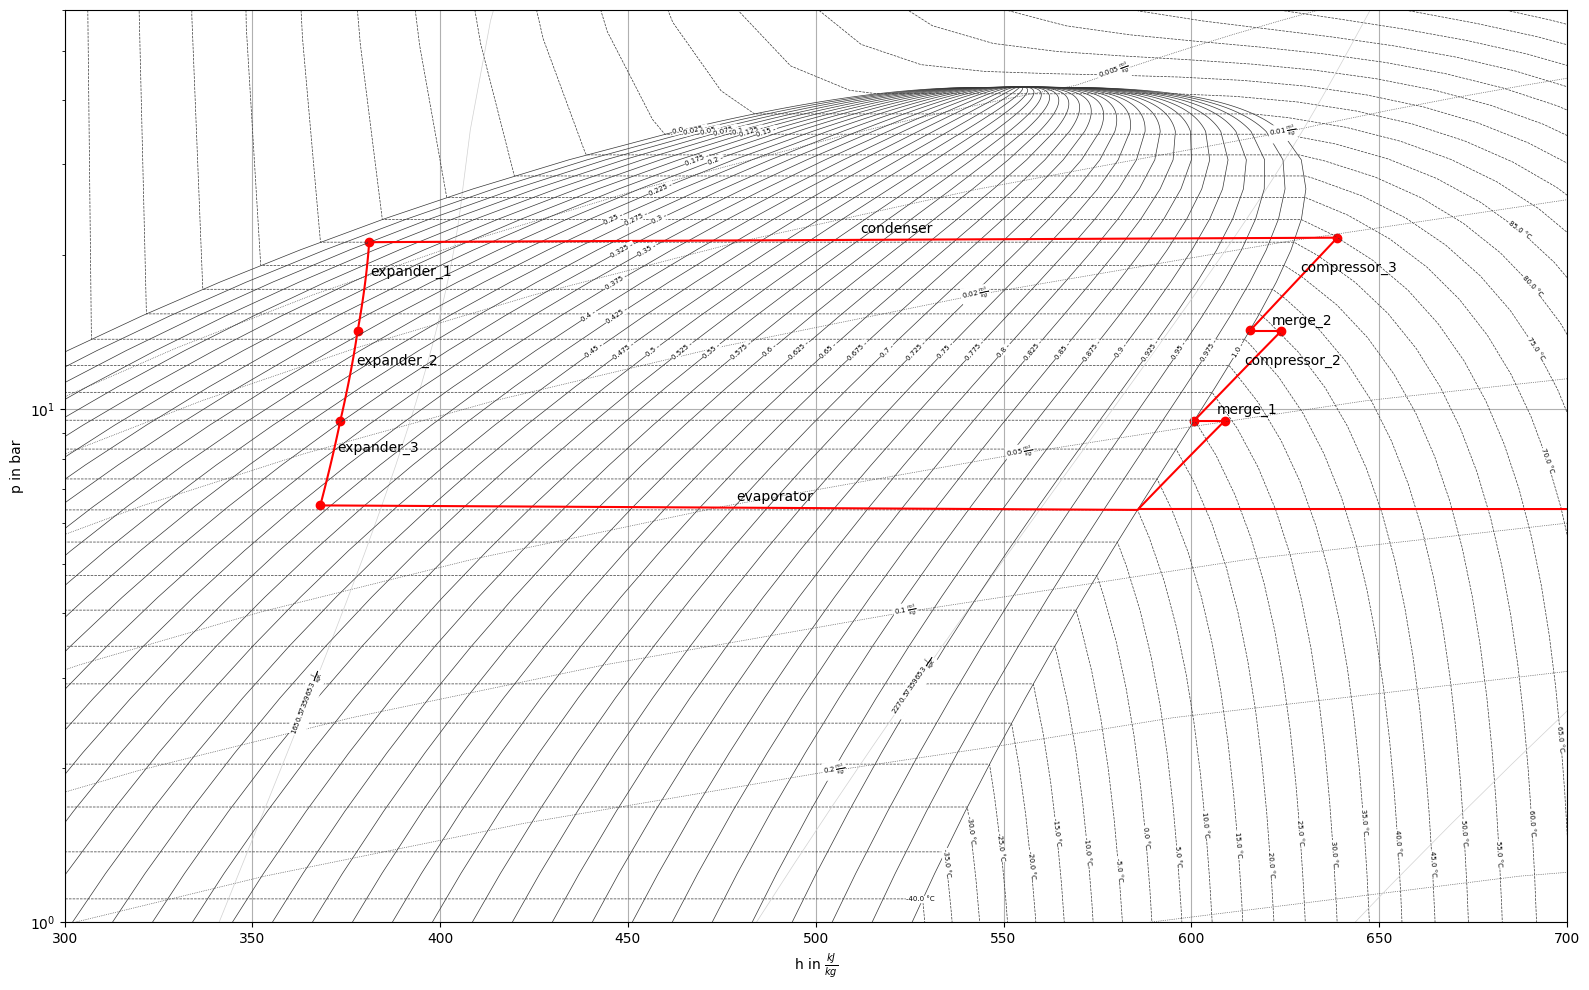

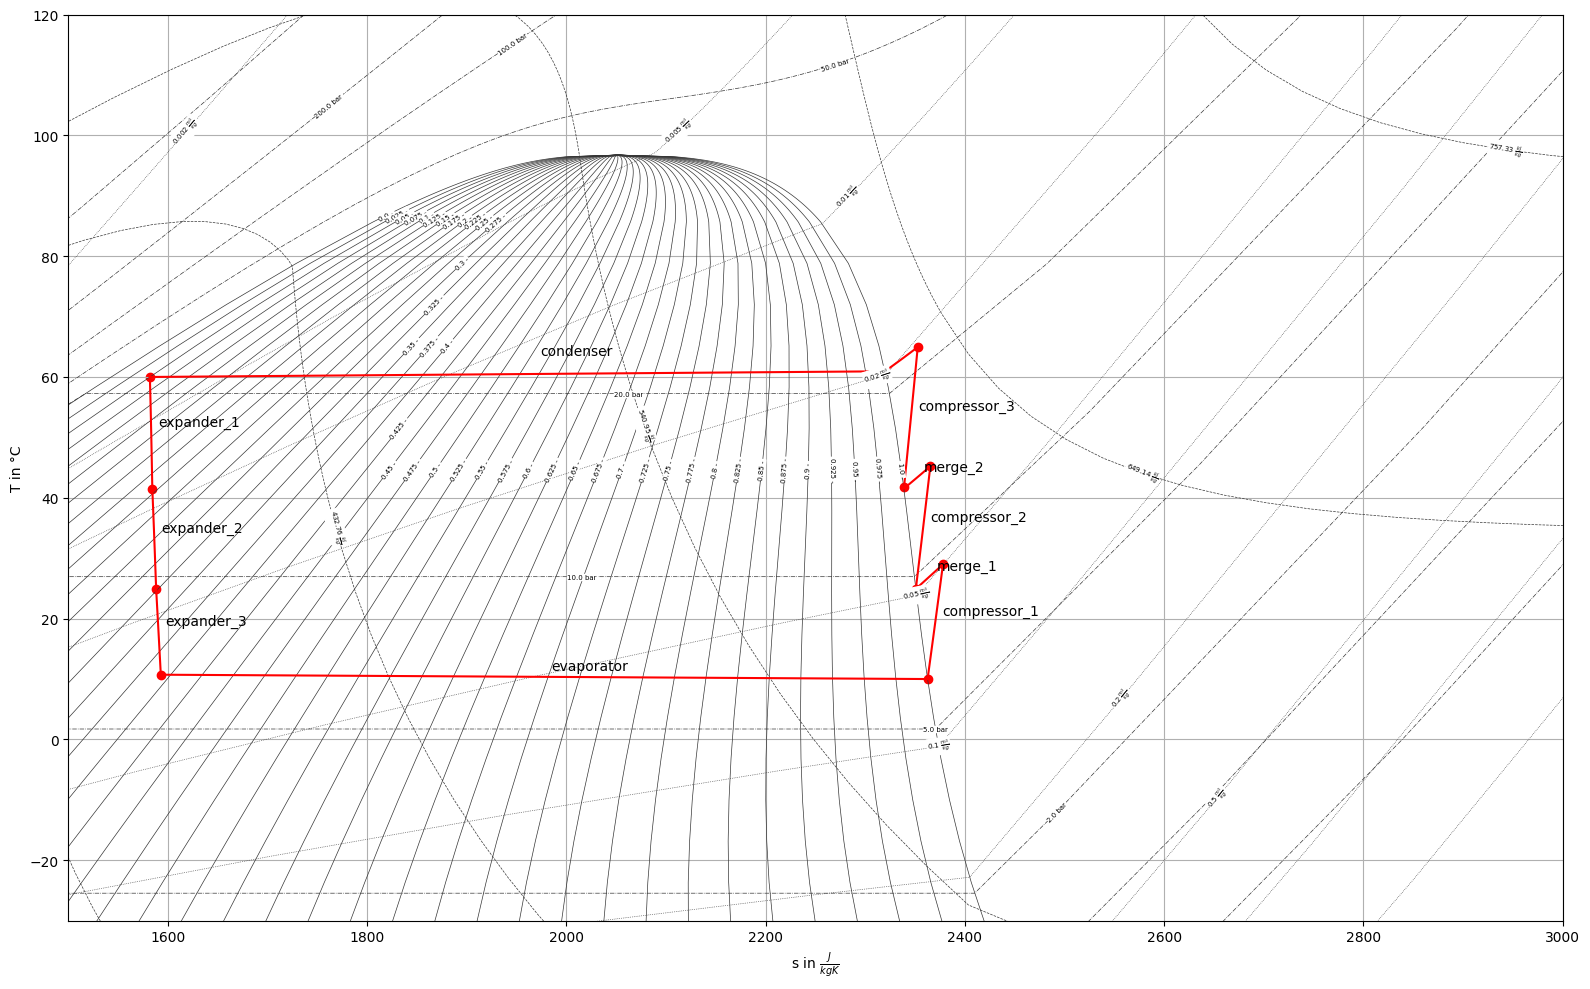

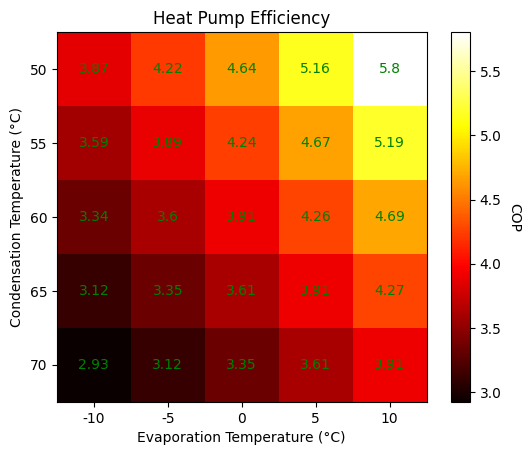

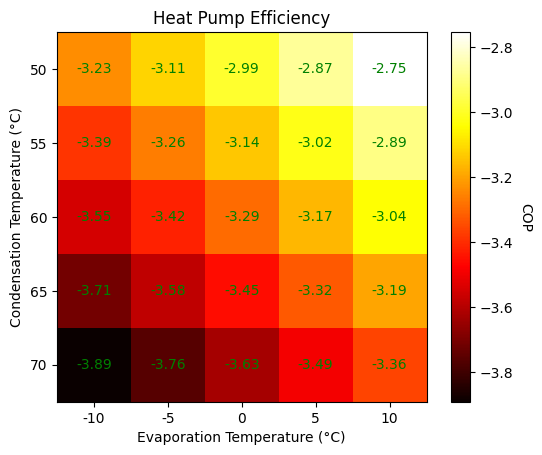

array([[-3.23363138, -3.11318122, -2.99233776, -2.87183776, -2.75265451],
       [-3.38598204, -3.26280684, -3.13911742, -3.01546639, -2.89255836],
       [-3.54511342, -3.41911191, -3.2925548 , -3.16585151, -3.0395105 ],
       [-3.71282775, -3.58380119, -3.45423596, -3.32442207, -3.1947117 ],
       [-3.89177427, -3.75944258, -3.62663964, -3.49355066, -3.360394  ]])

In [ ]:
from HPS_vapor_injection import VaporInjectionHeatPumpStudy
vapor_injection_study = VaporInjectionHeatPumpStudy(working_fluid=wf, N=2, expansion_device="expander"
                                                    ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap
                                                    ).solve(max_iter=50)
print(f"Vapor injection: DeltaT = {vapor_injection_study.get_delta_T():.2f} K")
vapor_injection_study.plot_logph_diag(f"output/vapor_injection_{N}_logph_diagram", x_max=700)
vapor_injection_study.plot_ts_diag(f"output/vapor_injection_{N}_ts_diagram", x_max=3000)
vapor_injection_study.plot_efficiency(f"output/vapor_injection_{N}_heat_pump_efficiency")
vapor_injection_study.plot_relative_efficiency(f"output/vapor_injection_{N}_heat_pump_relative_efficiency", expander_efficiency_matrix)

Vapor injection: DeltaT = 54.09 K


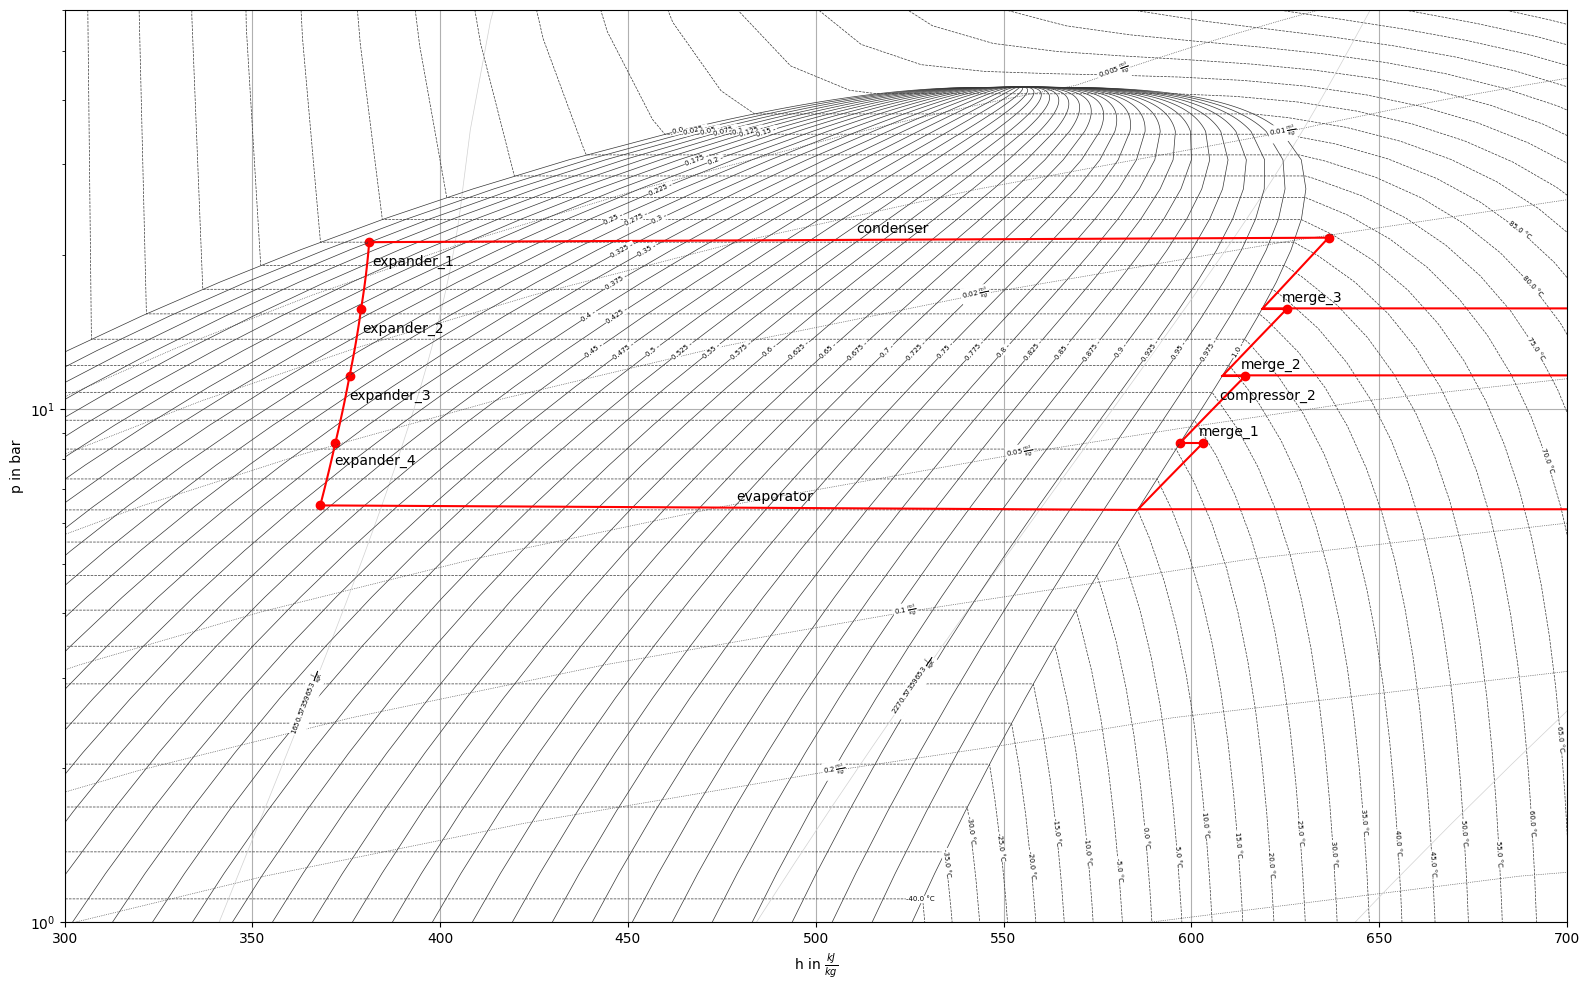

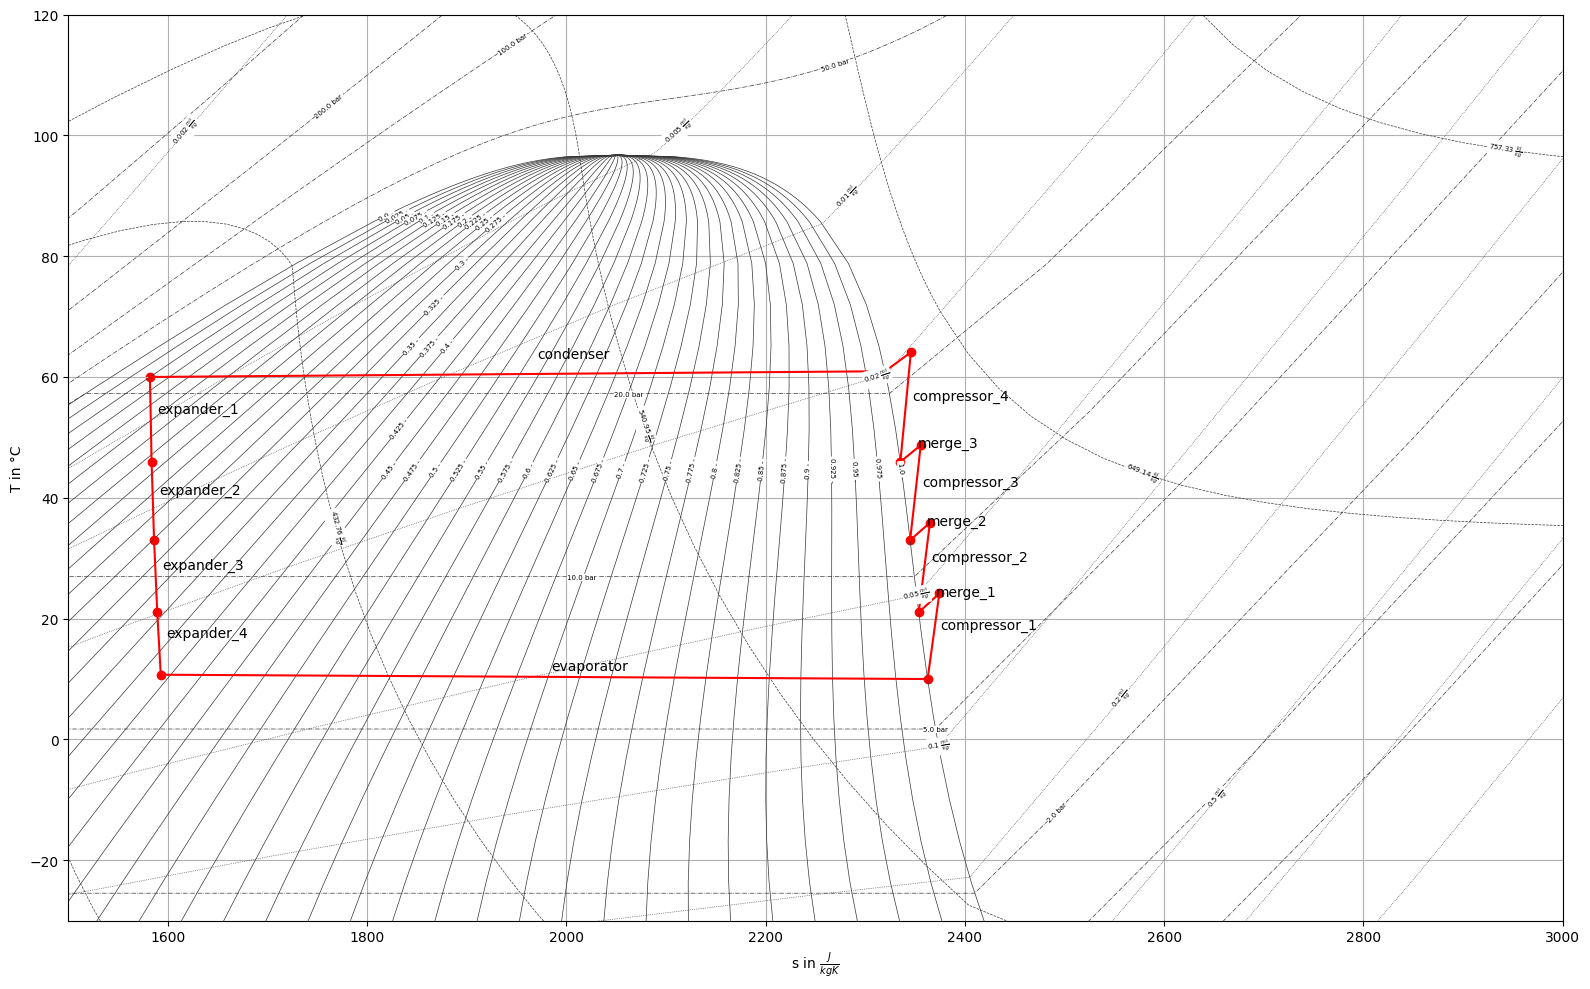

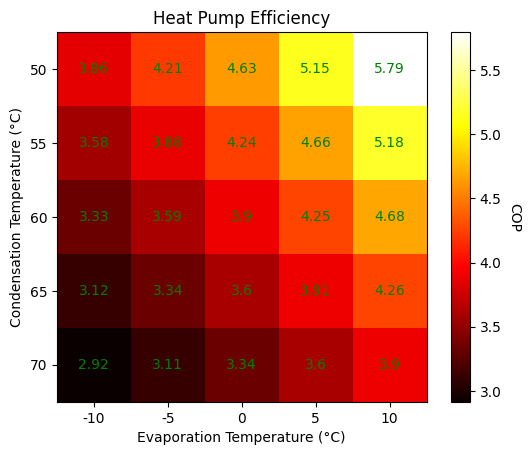

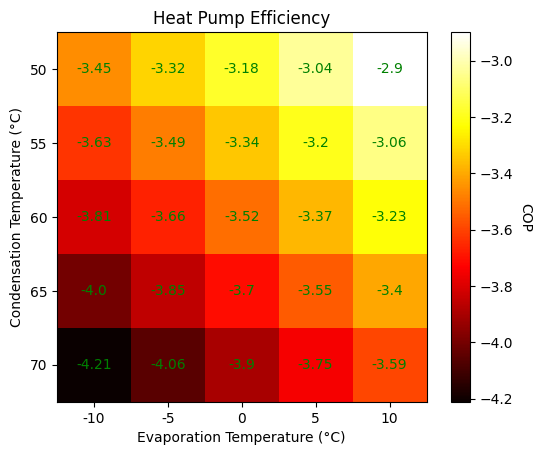

array([[-3.45483179, -3.31546272, -3.17566026, -3.03623221, -2.8982099 ],
       [-3.6288555 , -3.48619634, -3.34301293, -3.19992799, -3.0577021 ],
       [-3.81112983, -3.66497276, -3.5182798 , -3.37153021, -3.22528676],
       [-4.00400147, -3.85402095, -3.70354961, -3.55294789, -3.40262115],
       [-4.21095454, -4.05672345, -3.90209388, -3.74732304, -3.59268188]])

In [ ]:
from HPS_vapor_injection import VaporInjectionHeatPumpStudy
vapor_injection_study = VaporInjectionHeatPumpStudy(working_fluid=wf, N=3, expansion_device="expander"
                                                    ).set_boundary_conditions(T_cond=T_cond, T_evap=T_evap
                                                    ).solve(max_iter=50)
print(f"Vapor injection: DeltaT = {vapor_injection_study.get_delta_T():.2f} K")
vapor_injection_study.plot_logph_diag(f"output/vapor_injection_{N}_logph_diagram", x_max=700)
vapor_injection_study.plot_ts_diag(f"output/vapor_injection_{N}_ts_diagram", x_max=3000)
vapor_injection_study.plot_efficiency(f"output/vapor_injection_{N}_heat_pump_efficiency")
vapor_injection_study.plot_relative_efficiency(f"output/vapor_injection_{N}_heat_pump_relative_efficiency", expander_efficiency_matrix)